# Held-out validation of the CBA Ensemble's config choices

`cba_backtest.py`'s headline table and `grid_search.py`'s DTE x roll x bucket sweep both
fit/report on the **same single full-period window** (2022-08-12 -> 2026-06-10) -- there's
no train/test split anywhere in either script (confirmed: no `TRAIN`/`TEST`/`split`/
`walk_forward`/`holdout` reference in either file). `grid_search.py`'s own docstring says
it's checking whether `cba_backtest.py`'s TARGET_DTE=180/ROLL_DTE=14 defaults are
actually optimal -- but it answers that by picking a NEW winner on the exact same period,
which is in-sample parameter fitting, not out-of-sample proof.

This sandbox doesn't re-run the search. It takes the two configs that already exist and
checks them against held-out windows that were never used to pick either one:

| Config | Source | Bucket | Target DTE | Roll DTE | Stop-loss | Notes |
|---|---|---|---|---|---|---|
| A | `cba_backtest.py` headline default | 10% OTM | 180 | 14 | none | the published results.txt table |
| B | `grid_search.py` best-by-Sharpe, base costs | 10% OTM | 30 | 3 | 50% | `results/grid_search/cross_scenario_best.csv`, base row |

Both run through the real `simulate_ensemble()` -- same transaction costs (base: 1%/3%
per leg, vol/liquidity-scaled), same real TSLL borrow-rate series, same fill/liquidity
checks -- nothing re-derived, this is pure evaluation on windows the config choice never saw.

**Windows** (identical to the ones used earlier this session for the from-scratch rebuild,
for direct comparability -- now archived at `deprecated/scripts/sandbox/`):
- TRAIN: 2022-09-09 -> 2023-01-03 (decline) -- neither config was picked using this window
  alone, but it's part of the full period both were fit on, so it's not a clean holdout by
  itself. Included for continuity, not treated as proof.
- TEST A: 2024-12-17 -> 2025-04-08 (decline)
- TEST B: 2025-04-08 -> 2025-12-16 (rally)
- Continuous, everything after TRAIN_END through the end of data (2023-01-04 -> 2026-06-10)
  -- the more realistic risk measure established earlier this session.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from cba_backtest import simulate_ensemble
from grid_search import load_data
from metrics import summarize

%matplotlib inline
print("Imports OK")

Imports OK


## Load data once (full history, same as both scripts)

In [2]:
data = load_data()
(returns, tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
 tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma, borrow_df) = data

print(f"Full window: {returns.index.min().date()} -> {returns.index.max().date()} "
      f"({len(returns)} trading days)")

Full window: 2022-08-12 -> 2026-06-10 (960 trading days)


## Windows -- same dates as this session's earlier train/test split work

In [3]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END   = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END   = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END   = pd.Timestamp("2025-12-16")

idx = returns.index
WINDOWS = {
    "train": idx[(idx >= TRAIN_START) & (idx <= TRAIN_END)],
    "testA": idx[(idx >= TEST_A_START) & (idx <= TEST_A_END)],
    "testB": idx[(idx >= TEST_B_START) & (idx <= TEST_B_END)],
    "continuous_out_of_train": idx[idx > TRAIN_END],
}
for name, w in WINDOWS.items():
    print(f"{name:>24s}: {len(w):4d} days, {w.min().date()} -> {w.max().date()}")

                   train:   80 days, 2022-09-09 -> 2023-01-03
                   testA:   76 days, 2024-12-17 -> 2025-04-08
                   testB:  175 days, 2025-04-08 -> 2025-12-16
 continuous_out_of_train:  861 days, 2023-01-04 -> 2026-06-10


## The two candidate configs -- nothing re-derived, taken as-is from the existing scripts

In [4]:
MAX_DTE = 200  # same buffer grid_search.py uses over its 180 cap

# base cost scenario (grid_search.py's COST_SCENARIOS["base"]) -- realistic, not frictionless
TSLA_COST_PCT = 0.010
TSLL_COST_PCT = 0.030
tsll_borrow_rate = borrow_df["TSLL"]

CANDIDATES = {
    "A: cba_backtest.py headline (10%OTM/180/14, no stop-loss)": dict(
        moneyness_bucket="10% OTM", target_dte=180, roll_dte=14, stop_loss_pct=None),
    "B: grid_search.py best-by-Sharpe, base costs (10%OTM/30/3, 50% stop-loss)": dict(
        moneyness_bucket="10% OTM", target_dte=30, roll_dte=3, stop_loss_pct=0.5),
}
for name, cfg in CANDIDATES.items():
    print(name, "->", cfg)

A: cba_backtest.py headline (10%OTM/180/14, no stop-loss) -> {'moneyness_bucket': '10% OTM', 'target_dte': 180, 'roll_dte': 14, 'stop_loss_pct': None}
B: grid_search.py best-by-Sharpe, base costs (10%OTM/30/3, 50% stop-loss) -> {'moneyness_bucket': '10% OTM', 'target_dte': 30, 'roll_dte': 3, 'stop_loss_pct': 0.5}


## Run every candidate on every window

In [5]:
def run_one(win_dates, cfg):
    win_returns = returns.loc[win_dates]
    eq, stats = simulate_ensemble(
        win_returns,
        tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
        tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma,
        cfg["moneyness_bucket"], cfg["target_dte"], cfg["roll_dte"], MAX_DTE,
        stop_loss_pct=cfg["stop_loss_pct"],
        tsla_cost_pct=TSLA_COST_PCT, tsll_cost_pct=TSLL_COST_PCT,
        tsll_borrow_rate=tsll_borrow_rate)
    eq = eq / eq.iloc[0]
    return eq, stats

curves = {}
rows = []
for cand_name, cfg in CANDIDATES.items():
    curves[cand_name] = {}
    for win_name, win_dates in WINDOWS.items():
        eq, stats = run_one(win_dates, cfg)
        curves[cand_name][win_name] = eq
        row = summarize(eq, eq.pct_change().dropna(), cand_name)
        row["window"] = win_name
        row["fills"] = stats["fills"]
        row["misses"] = stats["misses"]
        row["exit_misses"] = stats["exit_misses"]
        row["stop_loss_rolls"] = stats["stop_loss_rolls"]
        row["transaction_costs_paid"] = round(stats["transaction_costs_paid"], 4)
        row["borrow_paid"] = round(stats["borrow_paid"], 4)
        rows.append(row)

results_df = pd.DataFrame(rows)[["Strategy", "window", "CAGR", "Ann. Vol", "Sharpe", "Max DD",
                                  "Calmar", "fills", "misses", "exit_misses", "stop_loss_rolls",
                                  "transaction_costs_paid", "borrow_paid"]]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
results_df

,Strategy,window,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,fills,misses,exit_misses,stop_loss_rolls,transaction_costs_paid,borrow_paid
0,"A: cba_backtest.py headline (10%OTM/180/14, no...",train,0.673946,0.380536,1.559881,-0.101303,6.652752,2,0,0,0,0.0141,0.0126
1,"A: cba_backtest.py headline (10%OTM/180/14, no...",testA,0.707366,0.377241,1.646692,-0.147671,4.790139,1,0,0,0,0.0033,0.0077
2,"A: cba_backtest.py headline (10%OTM/180/14, no...",testB,-0.316666,1.453461,0.409599,-0.424842,-0.745375,2,0,0,0,0.0527,0.0347
3,"A: cba_backtest.py headline (10%OTM/180/14, no...",continuous_out_of_train,-0.104776,3.626839,1.137172,-0.988499,-0.105995,9,0,2,0,0.5079,0.3263
4,"B: grid_search.py best-by-Sharpe, base costs (...",train,-0.468262,0.468804,-1.129092,-0.249211,-1.878980,1,0,0,11,0.0649,0.0126
5,"B: grid_search.py best-by-Sharpe, base costs (...",testA,-0.412351,0.439501,-1.028108,-0.241697,-1.706069,1,0,0,12,0.0256,0.0077
6,"B: grid_search.py best-by-Sharpe, base costs (...",testB,0.681592,1.189733,0.951003,-0.566390,1.203397,3,0,0,7,0.1035,0.0347
7,"B: grid_search.py best-by-Sharpe, base costs (...",continuous_out_of_train,0.807373,0.684550,1.190370,-0.563998,1.431518,25,0,2,57,1.2717,0.3263


## Equity curves, side by side, per window

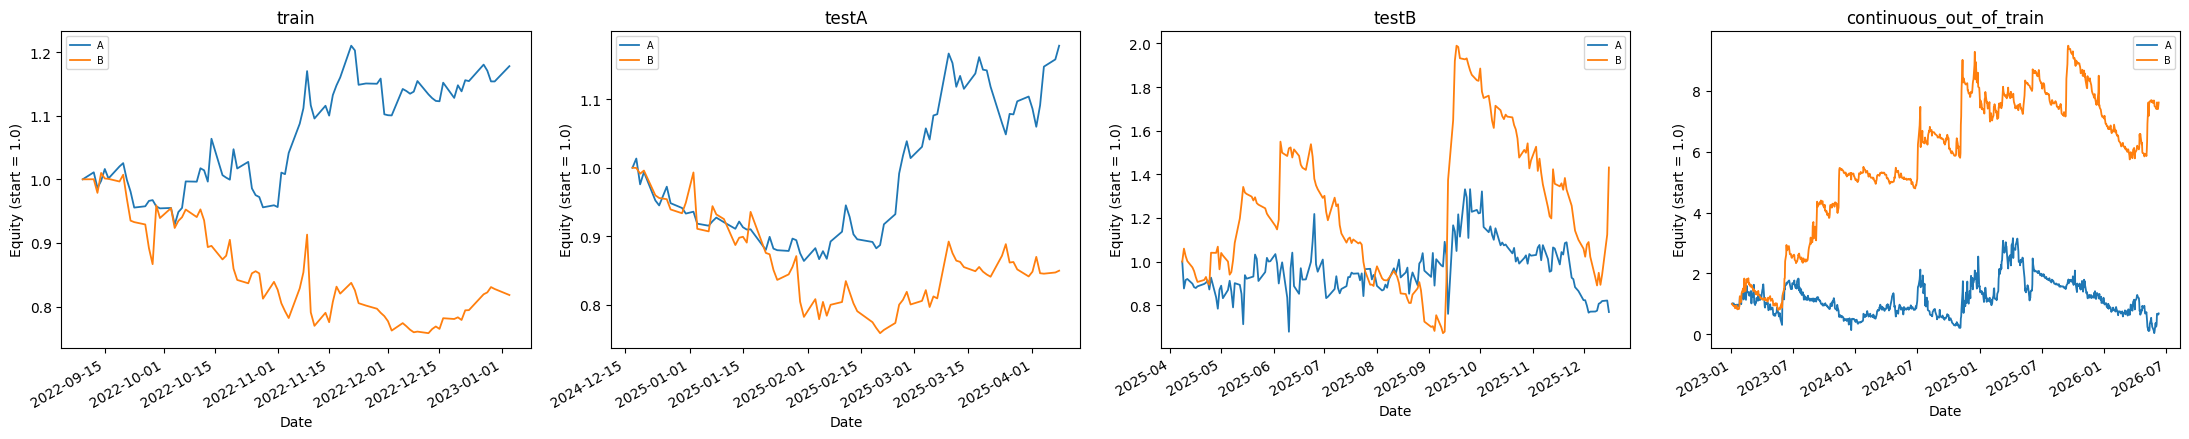

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, win_name in zip(axes, WINDOWS.keys()):
    for cand_name in CANDIDATES:
        curves[cand_name][win_name].plot(ax=ax, label=cand_name.split(":")[0], linewidth=1.3)
    ax.set_title(win_name)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## Sanity checks

In [7]:
for cand_name, per_window in curves.items():
    for win_name, eq in per_window.items():
        assert eq.isna().sum() == 0, f"{cand_name} / {win_name}: equity has NaNs"
        assert eq.min() > -5.0, f"{cand_name} / {win_name}: equity fell to an implausible level ({eq.min():.2f})"

print("Sanity checks passed -- no NaNs, no runaway/negative-equity blowups in any candidate/window.")
print("\nFull comparison:")
print(results_df.to_string(index=False))

Sanity checks passed -- no NaNs, no runaway/negative-equity blowups in any candidate/window.

Full comparison:
                                                                 Strategy                  window      CAGR  Ann. Vol    Sharpe    Max DD    Calmar  fills  misses  exit_misses  stop_loss_rolls  transaction_costs_paid  borrow_paid
                A: cba_backtest.py headline (10%OTM/180/14, no stop-loss)                   train  0.673946  0.380536  1.559881 -0.101303  6.652752      2       0            0                0                  0.0141       0.0126
                A: cba_backtest.py headline (10%OTM/180/14, no stop-loss)                   testA  0.707366  0.377241  1.646692 -0.147671  4.790139      1       0            0                0                  0.0033       0.0077
                A: cba_backtest.py headline (10%OTM/180/14, no stop-loss)                   testB -0.316666  1.453461  0.409599 -0.424842 -0.745375      2       0            0                0       